In [1]:
%pip install mat73 h5py scikit-learn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    '/Users/eom-jinyong/Downloads/데이터분석_MiniProject/Data'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : /Users/eom-jinyong/Downloads/데이터분석_MiniProject/Data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


In [4]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


In [8]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        raw_life = cell.get("cycle_life")
        life_array = np.asarray(raw_life, dtype=float).reshape(-1)

        cycle_life = (
            float(life_array[0])
            if life_array.size == 1 and np.isfinite(life_array[0])
            else np.nan
            )
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [9]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190.0,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190.0,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190.0,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190.0,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190.0,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [10]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [11]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [12]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


# Data PreProcessing

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_delta_q(cell, cycle_start=10, cycle_end=100):
    cycles = to_list_of_dicts(cell["cycles"])

    # 배열 인덱스와 실제 사이클 번호를 구분
    cycle_numbers = np.asarray(
        cell["summary"]["cycle"], dtype=float
    ).reshape(-1)

    if len(cycle_numbers) != len(cycles):
        raise ValueError(
            "summary의 사이클 수와 cycles 길이가 다릅니다. "
            "사이클 번호 매핑을 확인하세요."
        )

    def get_qdlin(cycle_number):
        matches = np.flatnonzero(cycle_numbers == cycle_number)

        if len(matches) != 1:
            raise ValueError(
                f"사이클 {cycle_number}를 하나로 식별할 수 없습니다."
            )

        # cycles[n]['Qdlin']에서 해당 사이클의 곡선 추출
        n = int(matches[0])
        raw = cycles[n]["Qdlin"]

        if raw is None:
            raise ValueError(f"사이클 {cycle_number}의 Qdlin이 없습니다.")

        return np.asarray(raw, dtype=float).reshape(-1)

    voltage = np.asarray(cell["Vdlin"], dtype=float).reshape(-1)
    q_start = get_qdlin(cycle_start)
    q_end = get_qdlin(cycle_end)

    if not (len(voltage) == len(q_start) == len(q_end)):
        raise ValueError("Vdlin과 두 Qdlin의 길이가 다릅니다.")

    valid = (
        np.isfinite(voltage)
        & np.isfinite(q_start)
        & np.isfinite(q_end)
    )

    if valid.sum() < 2:
        raise ValueError("비교할 수 있는 유효 전압점이 부족합니다.")

    voltage = voltage[valid]
    q_start = q_start[valid]
    q_end = q_end[valid]

    # 전압을 오름차순으로 정렬
    order = np.argsort(voltage)
    voltage = voltage[order]
    q_start = q_start[order]
    q_end = q_end[order]

    delta_q = q_end - q_start

    return voltage, q_start, q_end, delta_q


In [15]:
import numpy as np
import pandas as pd

curves = []
skipped = []

for cell_id, cell in enumerate(batch):
    try:
        life = float(np.asarray(cell["cycle_life"]).item())
        if not np.isfinite(life):
            raise ValueError("유효한 cycle_life가 없습니다.")

        voltage, _, _, delta_q = calculate_delta_q(cell)

        # 보간에 필요한 전압축 확인
        if np.any(np.diff(voltage) <= 0):
            raise ValueError("전압축에 중복값이 있습니다.")

        curves.append((cell_id, life, voltage, delta_q))

    except (ValueError, KeyError, TypeError) as error:
        skipped.append({"cell_id": cell_id, "reason": str(error)})

if not curves:
    raise ValueError("특징을 추출할 수 있는 셀이 없습니다.")

# 모든 셀의 공통 전압 범위
v_min = max(v.min() for _, _, v, _ in curves)
v_max = min(v.max() for _, _, v, _ in curves)

if v_min >= v_max:
    raise ValueError("셀 간 공통 전압 구간이 없습니다.")

voltage_grid = np.linspace(v_min, v_max, 1000)
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

records = []

for cell_id, life, voltage, delta_q in curves:
    dq = np.interp(voltage_grid, voltage, delta_q)

    group = (
        "Short" if life < 500
        else "Long" if life > 1000
        else "Middle"
    )

    records.append({
        "cell_id": cell_id,
        "cycle_life": life,
        "life_group": group,
        "dq_min": dq.min(),                         # Ah
        "dq_mean": dq.mean(),                       # Ah
        "dq_var": dq.var(),                         # Ah²
        "dq_abs_area": integrate(
            np.abs(dq), voltage_grid
        ),                                         # Ah·V
        "dq_min_voltage": voltage_grid[dq.argmin()], # V
    })

dq_features = pd.DataFrame(records)
display(dq_features.round(6))

feature_cols = [
    "dq_min", "dq_mean", "dq_var",
    "dq_abs_area", "dq_min_voltage",
]

# 그룹별 표본 수와 특징 중앙값
display(dq_features.groupby("life_group").size().rename("n_cells"))
display(
    dq_features.groupby("life_group")[feature_cols]
    .median()
    .round(6)
)

# 연속적인 수명과의 상관관계
correlations = pd.DataFrame({
    "Pearson": dq_features[feature_cols].corrwith(
        dq_features["cycle_life"], method="pearson"
    ),
    "Spearman": dq_features[feature_cols].corrwith(
        dq_features["cycle_life"], method="spearman"
    ),
})

display(
    correlations.sort_values(
        "Spearman", key=lambda x: x.abs(), ascending=False
    ).round(3)
)

if skipped:
    display(pd.DataFrame(skipped))

,cell_id,cycle_life,life_group,dq_min,dq_mean,dq_var,dq_abs_area,dq_min_voltage
0,0,1190.0,Long,-0.008460,-0.002873,0.000010,0.004437,3.064565
1,1,1179.0,Long,-0.011004,-0.004100,0.000010,0.006155,3.136637
2,2,1177.0,Long,-0.017216,-0.004487,0.000018,0.006737,3.153153
3,3,1226.0,Long,-0.018961,-0.007456,0.000036,0.011212,2.957958
4,4,1227.0,Long,-0.013958,-0.005750,0.000023,0.008635,2.878378
5,5,1074.0,Long,-0.025179,-0.011074,0.000066,0.016655,2.872372
6,6,636.0,Middle,-0.037886,-0.015965,0.000170,0.023977,2.933934
7,7,870.0,Middle,-0.038233,-0.016646,0.000154,0.024988,3.060060
8,8,879.0,Middle,-0.030808,-0.012819,0.000100,0.019245,2.941441
9,9,1054.0,Long,-0.028724,-0.011511,0.000087,0.017281,2.968468


life_group
Long      10
Middle    36
Name: n_cells, dtype: int64

,dq_min,dq_mean,dq_var,dq_abs_area,dq_min_voltage
life_group,,,,,
Long,-0.022070,-0.009265,0.000051,0.013933,2.954204
Middle,-0.038294,-0.017209,0.000164,0.025834,2.934685


,Pearson,Spearman
dq_var,-0.838,-0.871
dq_min,0.882,0.850
dq_mean,0.854,0.828
dq_abs_area,-0.854,-0.828
dq_min_voltage,0.312,0.056


In [16]:
# 기존 특징 테이블 복사
df = dq_features.copy()

# dq_min은 기존 컬럼 사용
# 분산이 음수·무한대이면 NaN 처리
valid_var = df['dq_var'].where(
    np.isfinite(df['dq_var']) & (df['dq_var'] >= 0)
)

df['log_dq_var'] = np.log10(valid_var + 1e-12)

In [18]:
df

,cell_id,cycle_life,life_group,dq_min,dq_mean,dq_var,dq_abs_area,dq_min_voltage,log_dq_var
0,0,1190.0,Long,-0.008460,-0.002873,0.000010,0.004437,3.064565,-5.014861
1,1,1179.0,Long,-0.011004,-0.004100,0.000010,0.006155,3.136637,-5.013960
2,2,1177.0,Long,-0.017216,-0.004487,0.000018,0.006737,3.153153,-4.737000
3,3,1226.0,Long,-0.018961,-0.007456,0.000036,0.011212,2.957958,-4.442613
4,4,1227.0,Long,-0.013958,-0.005750,0.000023,0.008635,2.878378,-4.647744
5,5,1074.0,Long,-0.025179,-0.011074,0.000066,0.016655,2.872372,-4.178878
6,6,636.0,Middle,-0.037886,-0.015965,0.000170,0.023977,2.933934,-3.768878
7,7,870.0,Middle,-0.038233,-0.016646,0.000154,0.024988,3.060060,-3.813486
8,8,879.0,Middle,-0.030808,-0.012819,0.000100,0.019245,2.941441,-4.001195
9,9,1054.0,Long,-0.028724,-0.011511,0.000087,0.017281,2.968468,-4.059384


# Regression 모델 설계 — Batch 1 학습 / Batch 2 최종 평가

이 섹션은 앞선 EDA 변수 상태와 독립적으로 실행할 수 있습니다. 아래 셀을 순서대로 실행하세요.
필요 패키지: numpy, pandas, matplotlib, h5py, scipy, scikit-learn.

- Target: `cycle_life`, 입력: `dq_min`, `log_dq_var`만 사용.
- 100사이클 완료 시점 예측: 실제 사이클 10·100의 Qdlin만 읽습니다. 전체 열화 속도,
  Knee, life_group, 마지막 관측 길이, 셀 ID, 프로토콜 문자열은 모델 입력에서 제외합니다.
- 셀당 한 행이며 셀 내부 시간 순서를 섞지 않습니다. Hold-out은 무작위 시점 분할이 아니라
  독립적인 셀의 **충전 프로토콜 그룹 분할**입니다. 단순 셀 Hold-out만으로는 프로토콜
  중복을 막지 못하므로 CV와 Hold-out 모두 동일 프로토콜의 셀을 함께 묶습니다.
- 먼저 Batch 1에서 Train/Valid를 분리한 뒤, 전압 격자 결정·중앙값 대체·스케일링은
  학습 부분에서만 fit합니다. CV 안에서도 같은 Pipeline을 사용합니다.
- Train 지표는 **Train 부분의 nested Group CV 평균 MAPE**입니다. 후보 모델 선택도
  이 지표만 사용합니다. Valid는 별도 Hold-out이며 CV fold가 아닙니다.
- Batch 2 파일은 모델 선택·튜닝·Valid 평가가 끝난 뒤 한 번 읽어 선택 모델만 평가합니다.
  Valid를 학습에 다시 넣지 않으므로 모든 최종 전처리는 Train 부분에서만 fit합니다.
- seed=42 고정. GroupKFold는 결정적 분할입니다. 타깃 IQR 이상치 삭제·샘플링은 하지 않습니다.
- 9.1%는 사용자가 지정한 논문 참고값입니다. 데이터/특징/분할이 다른 직접 재현 결과는 아닙니다.
  Classification은 이번 Regression 범위에 포함하지 않습니다.


In [1]:
from pathlib import Path
import json
import hashlib
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
MODEL_DATA_DIR = Path(globals().get('DATA_DIR',
    '/Users/eom-jinyong/Downloads/데이터분석_MiniProject/Data')).expanduser()
BATCH1_FILE = MODEL_DATA_DIR / '2017-05-12_batchdata_updated_struct_errorcorrect.mat'
BATCH2_FILE = MODEL_DATA_DIR / '2018-02-20_batchdata_updated_struct_errorcorrect.mat'
MODEL_OUTPUT_DIR = Path.cwd() / 'model_outputs'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES = ['dq_min', 'log_dq_var']
TARGET_MAPE = 9.1

def mape_percent(y_true, y_pred):
    return 100 * mean_absolute_percentage_error(y_true, y_pred)


## 원본 HDF5의 필요한 필드만 로드

수 GB의 모든 사이클을 메모리에 올리지 않고 실제 사이클 10·100의 곡선만 읽습니다.
summary의 실제 cycle 번호로 배열 위치를 확인합니다. 수명 NaN/비양수와 100사이클까지
관측되지 않은 셀은 사유와 함께 기록합니다. 이 모델의 적용 대상은 100사이클 생존 셀입니다.
곡선 일부가 잘못되어 특징 계산이 불가능하면 셀을 삭제하지 않고 특징을 NaN으로 유지합니다.
바코드는 알려진 경우 분할 간 동일 물리 셀 중복을 검사하는 용도로만 사용합니다.


In [2]:
def dereference(f, node):
    if isinstance(node, h5py.Dataset) and h5py.check_dtype(ref=node.dtype) is not None:
        refs = np.asarray(node).reshape(-1)
        if refs.size != 1:
            raise ValueError(f'단일 reference 예상: {node.name}')
        return f[refs[0]] if refs[0] else None
    return node

def numeric_value(f, node):
    node = dereference(f, node)
    if node is None or not isinstance(node, h5py.Dataset):
        return np.array([], dtype=float)
    if node.attrs.get('MATLAB_empty', 0):
        return np.array([], dtype=float)
    return np.asarray(node, dtype=float).reshape(-1)

def matlab_text(f, node):
    node = dereference(f, node)
    if node is None:
        return ''
    if isinstance(node, h5py.Group):
        # MATLAB string containers can contain a char data field.
        for key in ['data', 'Value', 'value']:
            if key in node:
                return matlab_text(f, node[key])
        return ''
    matlab_class = node.attrs.get('MATLAB_class', b'')
    if matlab_class in [b'string', 'string']:
        # MATLAB opaque string headers are not Unicode code points.
        return ''
    arr = np.asarray(node).reshape(-1)
    if arr.dtype.kind in 'ui':
        return ''.join(chr(int(v)) for v in arr if v).strip()
    if arr.dtype.kind in 'SU':
        return ''.join(v.decode() if isinstance(v, bytes) else str(v) for v in arr).strip()
    return ''

def cell_node(f, batch_group, field, index):
    refs = np.asarray(batch_group[field]).reshape(-1)
    return f[refs[index]] if refs[index] else None

def load_early_records(path, batch_name):
    rows, excluded = [], []
    with h5py.File(path, 'r') as f:
        b = f['batch']
        n_cells = np.asarray(b['cycle_life']).size
        for i in range(n_cells):
            uid = f'{batch_name}:cell_{i}'
            life_arr = numeric_value(f, cell_node(f, b, 'cycle_life', i))
            if life_arr.size != 1 or not np.isfinite(life_arr[0]) or life_arr[0] <= 0:
                excluded.append({'uid': uid, 'reason': '수명 누락/무효'})
                continue
            life = float(life_arr[0])
            if life <= 100:
                excluded.append({'uid': uid, 'reason': '100사이클 예측 대상 이전 EOL'})
                continue
            policy = ''
            for key in ['policy_readable', 'policy']:
                if key in b:
                    policy = matlab_text(f, cell_node(f, b, key, i))
                    if policy:
                        break
            if not policy:
                raise ValueError(f'{uid}: 프로토콜 식별 불가 — 누수 방지 그룹 분할 불가능')
            summary = cell_node(f, b, 'summary', i)
            cycle_numbers = numeric_value(f, summary['cycle'])
            indices = [np.flatnonzero(cycle_numbers == n) for n in [10, 100]]
            if any(len(idx) != 1 for idx in indices):
                excluded.append({'uid': uid, 'reason': '실제 사이클 10 또는 100 없음'})
                continue
            v = np.array([], dtype=float)
            dq = np.array([], dtype=float)
            feature_issue = ''
            try:
                cycle_group = cell_node(f, b, 'cycles', i)
                q_refs = np.asarray(cycle_group['Qdlin']).reshape(-1)
                if len(q_refs) != len(cycle_numbers):
                    raise ValueError('summary와 cycles 길이 불일치')
                q10 = numeric_value(f, f[q_refs[int(indices[0][0])]])
                q100 = numeric_value(f, f[q_refs[int(indices[1][0])]])
                v = numeric_value(f, cell_node(f, b, 'Vdlin', i))
                if not (len(v) == len(q10) == len(q100)) or len(v) < 2:
                    raise ValueError('Qdlin/Vdlin 길이 불일치 또는 결측')
                finite = np.isfinite(v) & np.isfinite(q10) & np.isfinite(q100)
                v, dq = v[finite], (q100 - q10)[finite]
                order = np.argsort(v)
                v, dq = v[order], dq[order]
                if len(v) < 2 or np.any(np.diff(v) <= 0):
                    raise ValueError('전압점 부족 또는 중복')
            except (ValueError, KeyError, TypeError, IndexError) as error:
                v, dq = np.array([]), np.array([])
                feature_issue = str(error)
            barcode = matlab_text(f, cell_node(f, b, 'barcode', i)) if 'barcode' in b else ''
            rows.append({'uid': uid, 'batch_id': batch_name, 'cell_id': i,
                         'charging_policy': policy.strip().lower(), 'barcode': barcode,
                         'cycle_life': life, 'voltage': v, 'delta_q': dq,
                         'feature_issue': feature_issue})
    return pd.DataFrame(rows), pd.DataFrame(excluded, columns=['uid', 'reason'])

# Batch 2는 여기서 열지 않습니다.
batch1_raw, batch1_excluded = load_early_records(BATCH1_FILE, 'Batch 1')
assert not batch1_raw.empty
display(batch1_excluded)
display(batch1_raw[['uid', 'charging_policy', 'cycle_life', 'feature_issue']])


,uid,reason


,uid,charging_policy,cycle_life,feature_issue
0,Batch 1:cell_0,3.6c(80%)-3.6c,1190.0,
1,Batch 1:cell_1,3.6c(80%)-3.6c,1179.0,
2,Batch 1:cell_2,3.6c(80%)-3.6c,1177.0,
3,Batch 1:cell_3,4c(80%)-4c,1226.0,
4,Batch 1:cell_4,4c(80%)-4c,1227.0,
5,Batch 1:cell_5,4.4c(80%)-4.4c,1074.0,
6,Batch 1:cell_6,4.8c(80%)-4.8c,636.0,
7,Batch 1:cell_7,4.8c(80%)-4.8c,870.0,
8,Batch 1:cell_8,5.4c(40%)-3.6c,879.0,
9,Batch 1:cell_9,5.4c(40%)-3.6c,1054.0,


In [3]:
# 특징 처리보다 먼저 셀/프로토콜 그룹 분할
holdout_splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, valid_idx = next(holdout_splitter.split(
    batch1_raw, groups=batch1_raw['charging_policy']))
train_raw = batch1_raw.iloc[train_idx].reset_index(drop=True)
valid_raw = batch1_raw.iloc[valid_idx].reset_index(drop=True)

assert set(train_raw['uid']).isdisjoint(valid_raw['uid'])
assert set(train_raw['charging_policy']).isdisjoint(valid_raw['charging_policy'])
def known_barcodes(frame):
    return {v for v in frame['barcode'] if v and v.lower() not in ['unknown', 'none', 'nan']}
assert known_barcodes(train_raw).isdisjoint(known_barcodes(valid_raw)), '동일 물리 셀의 중복 분할을 확인하세요.'
if train_raw['charging_policy'].nunique() < 4:
    raise ValueError('Nested group CV에 필요한 프로토콜 수가 부족합니다.')

split_manifest = pd.concat([
    train_raw.assign(split='Train'), valid_raw.assign(split='Valid')
])[['uid', 'charging_policy', 'barcode', 'split']]
split_manifest.to_csv(MODEL_OUTPUT_DIR / 'batch1_split_manifest.csv', index=False)
display(split_manifest.groupby('split').agg(
    n_cells=('uid', 'size'), n_protocols=('charging_policy', 'nunique')))

# 모델 X에는 초기 곡선만 포함합니다. 타깃/ID/프로토콜은 제외합니다.
X_train = train_raw[['voltage', 'delta_q']].copy()
y_train = train_raw['cycle_life'].to_numpy()
X_valid = valid_raw[['voltage', 'delta_q']].copy()
y_valid = valid_raw['cycle_life'].to_numpy()
train_groups = train_raw['charging_policy'].to_numpy()


,n_cells,n_protocols
split,,
Train,33,17
Valid,13,6


## CV 내부 특징 추출·전처리

공통 전압 범위는 각 fold의 train만으로 결정하며 Valid/Test를 보고 변경하지 않습니다.
고정 격자를 포함하지 못하는 곡선은 외삽하지 않고 NaN으로 처리한 후 train 중앙값으로 대체합니다.
`dq_min = min(Q100-Q10)`、`log_dq_var = log10(var(Q100-Q10)+1e-12)`。
단발성 변동은 추측으로 삭제하지 않습니다. 원본 곡선을 보존하고 특징 오류를 감사 표에 기록합니다.
타깃에서 파생된 입력은 없으며 IQR 기준으로 장수명 셀을 자동 제외하지 않습니다.


In [4]:
class DeltaQFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, n_points=1000, epsilon=1e-12):
        self.n_points = n_points
        self.epsilon = epsilon

    def fit(self, X, y=None):
        usable = [v for v in X['voltage'] if len(v) >= 2]
        if not usable:
            raise ValueError('train에 유효한 초기 곡선이 없습니다.')
        lo = max(float(v[0]) for v in usable)
        hi = min(float(v[-1]) for v in usable)
        if lo >= hi:
            raise ValueError('train의 공통 전압 구간이 없습니다.')
        self.voltage_grid_ = np.linspace(lo, hi, self.n_points)
        return self

    def transform(self, X):
        rows = []
        lo, hi = self.voltage_grid_[[0, -1]]
        for v, dq in zip(X['voltage'], X['delta_q']):
            if len(v) < 2 or v[0] > lo + 1e-9 or v[-1] < hi - 1e-9:
                rows.append([np.nan, np.nan])
                continue
            values = np.interp(self.voltage_grid_, v, dq)
            rows.append([values.min(), np.log10(values.var(ddof=0) + self.epsilon)])
        return np.asarray(rows, dtype=float)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(FEATURES, dtype=object)

def make_pipeline(model):
    return Pipeline([
        ('features', DeltaQFeatures()),
        ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('scaler', StandardScaler()),
        ('model', model),
    ])

candidate_specs = {
    'Dummy': (DummyRegressor(strategy='median'), {}),
    'Ridge': (Ridge(), {'model__alpha': [0.01, 0.1, 1, 10, 100]}),
    'ElasticNet': (ElasticNet(max_iter=30000, random_state=RANDOM_STATE), {
        'model__alpha': [0.1, 1, 10], 'model__l1_ratio': [0.2, 0.8]}),
    'RBF-SVR': (SVR(kernel='rbf'), {
        'model__C': [100, 1000], 'model__gamma': ['scale', 0.1],
        'model__epsilon': [10, 50]}),
    'RandomForest': (RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=1), {
        'model__max_depth': [2, 4], 'model__min_samples_leaf': [2, 4]}),
    'GradientBoosting': (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        'model__n_estimators': [50, 100], 'model__learning_rate': [0.03, 0.1],
        'model__max_depth': [1, 2], 'model__min_samples_leaf': [3]}),
}

def group_cv(groups, max_splits=3):
    n = min(max_splits, len(np.unique(groups)))
    if n < 2:
        raise ValueError('group CV에 필요한 프로토콜이 부족합니다.')
    return GroupKFold(n_splits=n)

def tune_model(pipe, params, X, y, groups):
    search = GridSearchCV(
        pipe, params, scoring='neg_mean_absolute_percentage_error',
        cv=group_cv(groups), refit=True, n_jobs=1, error_score='raise')
    search.fit(X, y, groups=groups)
    return search


In [5]:
# Nested CV: 바깥 fold로 평가하고 안쪽 fold에서만 하이퍼파라미터를 선택합니다.
cv_rows, tuning_rows, fitted_candidates = [], [], {}
outer_splits = list(group_cv(train_groups).split(X_train, y_train, train_groups))

for name, (model, params) in candidate_specs.items():
    print(f'Nested CV: {name}', flush=True)
    for fold, (fit_idx, eval_idx) in enumerate(outer_splits, start=1):
        assert set(train_groups[fit_idx]).isdisjoint(train_groups[eval_idx])
        search = tune_model(make_pipeline(clone(model)), params,
                            X_train.iloc[fit_idx], y_train[fit_idx], train_groups[fit_idx])
        pred = search.predict(X_train.iloc[eval_idx])
        cv_rows.append({'model': name, 'fold': fold,
                        'MAPE_pct': mape_percent(y_train[eval_idx], pred),
                        'n_fit': len(fit_idx), 'n_eval': len(eval_idx)})
# 고정된 Train에만 fit. Valid/Test는 아직 사용하지 않음.
    final_search = tune_model(make_pipeline(clone(model)), params,
                              X_train, y_train, train_groups)
    fitted_candidates[name] = final_search.best_estimator_
    tuning_rows.append({'model': name, 'best_params': final_search.best_params_})

cv_detail = pd.DataFrame(cv_rows)
cv_summary = cv_detail.groupby('model')['MAPE_pct'].agg(
    Train_CV_MAPE='mean', CV_std='std').sort_values('Train_CV_MAPE')
winner = cv_summary.index[0]  # CV 결과만으로 선택하고 이후 변경하지 않습니다.
selected_model = fitted_candidates[winner]
display(cv_summary.round(3))
display(pd.DataFrame(tuning_rows))
print('CV만으로 확정한 최종 모델:', winner)

selection_lock = {
    'winner': winner, 'random_state': RANDOM_STATE, 'features': FEATURES,
    'train_uids': train_raw['uid'].tolist(), 'valid_uids': valid_raw['uid'].tolist(),
    'cv_mean_mape': float(cv_summary.loc[winner, 'Train_CV_MAPE']),
    'best_params': next(r['best_params'] for r in tuning_rows if r['model'] == winner),
    'target_reference_mape': TARGET_MAPE,
}
(MODEL_OUTPUT_DIR / 'selection_lock.json').write_text(
    json.dumps(selection_lock, ensure_ascii=False, indent=2), encoding='utf-8')
cv_detail.to_csv(MODEL_OUTPUT_DIR / 'batch1_nested_cv.csv', index=False)

selection_signature = hashlib.sha256(
    json.dumps(selection_lock, sort_keys=True).encode()).hexdigest()


Nested CV: Dummy
Nested CV: Ridge
Nested CV: ElasticNet
Nested CV: RBF-SVR
Nested CV: RandomForest
Nested CV: GradientBoosting
CV만으로 확정한 최종 모델: Ridge


,Train_CV_MAPE,CV_std
model,,
Ridge,7.894,0.972
ElasticNet,8.268,1.475
RandomForest,9.711,2.518
RBF-SVR,10.426,3.024
GradientBoosting,11.099,3.250
Dummy,23.062,5.505


,model,best_params
0,Dummy,{}
1,Ridge,{'model__alpha': 0.1}
2,ElasticNet,"{'model__alpha': 0.1, 'model__l1_ratio': 0.8}"
3,RBF-SVR,"{'model__C': 1000, 'model__epsilon': 10, 'mode..."
4,RandomForest,"{'model__max_depth': 4, 'model__min_samples_le..."
5,GradientBoosting,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [6]:
# Valid는 모델 선택에 사용하지 않고 고정된 모델의 독립적인 평가에 사용
valid_scores = {}
valid_predictions = {}
for name, model in fitted_candidates.items():
    pred = model.predict(X_valid)
    valid_scores[name] = mape_percent(y_valid, pred)
    valid_predictions[name] = pred

candidate_performance = cv_summary.copy()
candidate_performance['Valid_Holdout_MAPE'] = pd.Series(valid_scores)
candidate_performance['Gap_Train_Valid_pp'] = (
    candidate_performance['Train_CV_MAPE'] - candidate_performance['Valid_Holdout_MAPE'])
display(candidate_performance.round(3))
candidate_performance.to_csv(MODEL_OUTPUT_DIR / 'batch1_candidate_performance.csv')

final_feature_audit = pd.DataFrame(
    selected_model.named_steps['features'].transform(X_train), columns=FEATURES)
final_feature_audit.insert(0, 'uid', train_raw['uid'].to_numpy())
display(final_feature_audit)
final_feature_audit.to_csv(MODEL_OUTPUT_DIR / 'train_feature_audit.csv', index=False)


,Train_CV_MAPE,CV_std,Valid_Holdout_MAPE,Gap_Train_Valid_pp
model,,,,
Ridge,7.894,0.972,12.557,-4.663
ElasticNet,8.268,1.475,11.278,-3.010
RandomForest,9.711,2.518,7.288,2.423
RBF-SVR,10.426,3.024,8.372,2.054
GradientBoosting,11.099,3.250,6.384,4.715
Dummy,23.062,5.505,14.203,8.859


,uid,dq_min,log_dq_var
0,Batch 1:cell_3,-0.018961,-4.442613
1,Batch 1:cell_4,-0.013958,-4.647744
2,Batch 1:cell_5,-0.025179,-4.178878
3,Batch 1:cell_6,-0.037886,-3.768878
4,Batch 1:cell_7,-0.038233,-3.813486
5,Batch 1:cell_8,-0.030808,-4.001195
6,Batch 1:cell_9,-0.028724,-4.059384
7,Batch 1:cell_10,-0.026993,-4.022573
8,Batch 1:cell_11,-0.023692,-4.146897
9,Batch 1:cell_12,-0.027439,-4.125191


## 최종 Test — 이 단계 전에 모델 설계 확정

Test는 선택된 모델만 평가합니다. 후보 모델별 Test 비교나 Test 결과에 따른 재조정은
수행하지 않습니다. 동일 커널에서 이 셀을 다시 실행하면 저장된 결과만 표시합니다.
Batch 2의 수명 NaN은 제외하고 대상 셀 수와 제외 이유를 저장합니다. 알려진 바코드 또는
완전히 일치하는 초기 곡선이 Batch 1과 중복되면 평가를 중단합니다.


In [7]:
if '_ess_final_test_cache' not in globals():
    # Test 읽기는 이 위치에서만 수행합니다.
    test_raw, test_excluded = load_early_records(BATCH2_FILE, 'Batch 2')
    if test_raw.empty:
        raise ValueError('Batch 2에 평가할 셀이 없습니다.')
    overlap = known_barcodes(batch1_raw) & known_barcodes(test_raw)
    if overlap:
        raise ValueError(f'Batch 간 동일 물리 셀 barcode 중복: {overlap}')
    def curve_fingerprint(row):
        if len(row['voltage']) < 2:
            return None
        return hashlib.sha256(
            np.asarray(row['voltage'], dtype='<f8').tobytes()
            + np.asarray(row['delta_q'], dtype='<f8').tobytes()).hexdigest()
    fingerprints1 = {curve_fingerprint(r) for _, r in batch1_raw.iterrows()} - {None}
    fingerprints2 = {curve_fingerprint(r) for _, r in test_raw.iterrows()} - {None}
    if fingerprints1 & fingerprints2:
        raise ValueError('Batch 간 완전히 일치하는 초기 곡선이 있습니다. 중복 셀을 확인하세요.')
    X_test = test_raw[['voltage', 'delta_q']].copy()
    y_test = test_raw['cycle_life'].to_numpy()
    test_pred = selected_model.predict(X_test)  # 최종 Test 예측은 한 번만 수행합니다.
    test_mape = mape_percent(y_test, test_pred)
    train_mape = float(cv_summary.loc[winner, 'Train_CV_MAPE'])
    valid_mape = valid_scores[winner]
    performance = pd.DataFrame({
        'Index': ['Train (Batch 1 CV)', 'Valid (Batch 1 Hold-out)', 'Test (Batch 2)',
                  'Gap (Train-Valid)', 'Gap (Valid-Test)', 'Gap (Target-Test)'],
        'Value': [train_mape, valid_mape, test_mape,
                  train_mape - valid_mape, valid_mape - test_mape, TARGET_MAPE - test_mape],
        'Unit': ['MAPE (%)'] * 3 + ['percentage points'] * 3,
    }).set_index('Index')
    predictions = test_raw[['uid', 'charging_policy', 'cycle_life', 'feature_issue']].copy()
    predictions['predicted_cycle_life'] = test_pred
    predictions['APE_pct'] = 100 * np.abs(test_pred - y_test) / y_test
    test_features = pd.DataFrame(
        selected_model.named_steps['features'].transform(X_test), columns=FEATURES)
    predictions['features_missing_before_imputation'] = test_features.isna().any(axis=1).to_numpy()
    performance.to_csv(MODEL_OUTPUT_DIR / 'selected_model_performance.csv')
    predictions.to_csv(MODEL_OUTPUT_DIR / 'batch2_predictions.csv', index=False)
    test_excluded.to_csv(MODEL_OUTPUT_DIR / 'batch2_exclusions.csv', index=False)
    _ess_final_test_cache = {'winner': winner, 'performance': performance,
        'predictions': predictions, 'excluded': test_excluded,
        'n_train': len(train_raw), 'n_valid': len(valid_raw), 'n_test': len(test_raw),
        'selection_signature': selection_signature}
elif (_ess_final_test_cache['winner'] != winner
      or _ess_final_test_cache['selection_signature'] != selection_signature):
    raise RuntimeError('Test 평가 후 모델을 변경할 수 없습니다. 저장 결과를 유지하세요.')

print('선택 모델:', _ess_final_test_cache['winner'])
print('Train/Valid/Test 셀 수:',
      [_ess_final_test_cache[k] for k in ['n_train', 'n_valid', 'n_test']])
display(_ess_final_test_cache['performance'].round(3))
display(_ess_final_test_cache['excluded'])
display(_ess_final_test_cache['predictions'].round(3))


선택 모델: Ridge
Train/Valid/Test 셀 수: [33, 13, 39]


,Value,Unit
Index,,
Train (Batch 1 CV),7.894,MAPE (%)
Valid (Batch 1 Hold-out),12.557,MAPE (%)
Test (Batch 2),25.468,MAPE (%)
Gap (Train-Valid),-4.663,percentage points
Gap (Valid-Test),-12.911,percentage points
Gap (Target-Test),-16.368,percentage points


,uid,reason
0,Batch 2:cell_22,수명 누락/무효
1,Batch 2:cell_23,수명 누락/무효
2,Batch 2:cell_35,수명 누락/무효
3,Batch 2:cell_36,수명 누락/무효
4,Batch 2:cell_37,수명 누락/무효
5,Batch 2:cell_38,수명 누락/무효
6,Batch 2:cell_39,수명 누락/무효
7,Batch 2:cell_40,수명 누락/무효


,uid,charging_policy,cycle_life,feature_issue,predicted_cycle_life,APE_pct,features_missing_before_imputation
0,Batch 2:cell_0,5.2c(58%)-4c,477.0,,624.938,31.014,False
1,Batch 2:cell_1,5.6c(26%)-4.5c,491.0,,527.319,7.397,False
2,Batch 2:cell_2,5.2c(50%)-4.25c,424.0,,602.981,42.213,False
3,Batch 2:cell_3,4.65c(44%)-5c,499.0,,632.293,26.712,False
4,Batch 2:cell_4,4.65c(69%)-6c,444.0,,494.226,11.312,False
5,Batch 2:cell_5,3.6c(30%)-6c,416.0,,433.478,4.202,False
6,Batch 2:cell_6,3.6c(9%)-5c,393.0,,641.506,63.233,False
7,Batch 2:cell_7,4.8c(80%)-4.8c-newstructure,777.0,,1029.772,32.532,False
8,Batch 2:cell_8,5.2c(58%)-4c-newstructure,904.0,,960.132,6.209,False
9,Batch 2:cell_9,5.6c(26%)-4.5c-newstructure,791.0,,1097.357,38.730,False


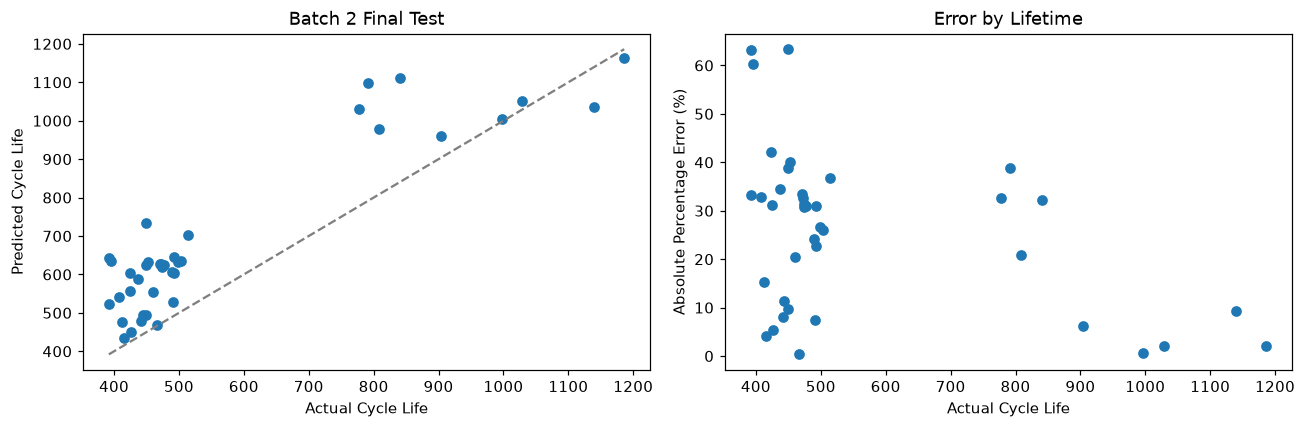

In [8]:
predictions = _ess_final_test_cache['predictions']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(predictions['cycle_life'], predictions['predicted_cycle_life'])
lo = min(predictions['cycle_life'].min(), predictions['predicted_cycle_life'].min())
hi = max(predictions['cycle_life'].max(), predictions['predicted_cycle_life'].max())
axes[0].plot([lo, hi], [lo, hi], '--', color='gray')
axes[0].set(xlabel='Actual Cycle Life', ylabel='Predicted Cycle Life', title='Batch 2 Final Test')
axes[1].scatter(predictions['cycle_life'], predictions['APE_pct'])
axes[1].set(xlabel='Actual Cycle Life', ylabel='Absolute Percentage Error (%)', title='Error by Lifetime')
plt.tight_layout()
plt.show()


## 지표 해석과 한계

- MAPE는 작을수록 좋습니다. Gap은 요청대로 **왼쪽−오른쪽**이며, 음수는 오른쪽 오차가 더 큼을 뜻합니다.
- Train−Valid는 CV 평균과 독립 Hold-out의 차이입니다. 일반적인 학습 내 오차와의 차이가 아니므로
  차이는 과적합뿐 아니라 검증 프로토콜의 난이도와 소표본 변동도 반영합니다.
- Valid−Test는 Batch 간 일반화 차이, Target−Test는 9.1% 참고값과의 차이(percentage points)입니다.
- Batch 간 조건·수명 분포가 달라 Test 오차가 증가할 수 있습니다. 결과를 보고 Test에
  맞춘 튜닝을 수행하지 않습니다. 이후 추가 실험은 새로운 미사용 평가 데이터가 필요합니다.
- 누락 수명이 EOL 미도달에 따른 중도 종료라면 일반 회귀에서 제외할 때의 선택 편향을 확인해야 합니다.
  원본 cycle_life를 사용하며 EOL 정의나 연속 측정 보정은 추측으로 변경하지 않습니다.
- 바코드를 읽지 못한 셀의 물리적 독립성은 파일 기록만으로 완전히 보장할 수 없습니다.
- Pipeline은 전처리 fit 범위를 제한합니다. 이후 실운용에서도 특징 추출 사양을 고정해야 합니다.


## 실행 결과 (고정 모델 / 최종 Test 1회 평가)

PDF 모델 설계에 따라 `dq_min`, `log_dq_var`만 입력했습니다.
Batch 1: Train 33셀(17개 프로토콜), Valid 13셀(6개 프로토콜).
Batch 2: Test 39셀, 수명 NaN 8셀 제외. CV 평균으로 Ridge(alpha=0.1)를 선택했습니다.

| Index | MAPE 또는 Gap |
|---|---:|
| Train (Batch 1 nested CV) | 7.894% |
| Valid (Batch 1 Hold-out) | 12.557% |
| Test (Batch 2) | 25.468% |
| Gap (Train-Valid) | -4.663 pp |
| Gap (Valid-Test) | -12.911 pp |
| Gap (Target-Test), 9.1%-Test | -16.368 pp |

Batch 2 오차가 더 커 Batch 간 일반화 차이가 관찰됩니다. 이 결과를 이용한 재튜닝은 하지 않았습니다.
Train Gap은 학습 내 오차가 아니라 nested CV와 Hold-out의 차이이므로 과적합만의 증거로 해석하지 않습니다.
후보 전체의 CV/Valid 표와 선택 모델의 Test 예측·오차 그래프가 위 실행 출력에 포함되어 있습니다.
